# 2026 Sanriku-oki M6.9 (us6000t7zq) — moment tensor + finite-fault, with a twist

**Event:** 2026-06-24 22:30:12.99 UTC, 40.2515°N 142.1614°E, origin depth 34 km, Mww 6.9 —
an interplate thrust on the Japan Trench interface, **25 minutes after the Venezuela M7.2+M7.5
doublet**. USGS published W-phase and body-wave MTs but **no finite-fault model**.

**The twist (and our hypothesis for the missing USGS FFM):** the Venezuela doublet's global
surface wavetrain sweeps this event's teleseismic analysis windows. Quantified below:
**18/26 surface-wave windows and 6/26 body-wave windows are contaminated**; the W-phase/body-MT
windows close before the train arrives (why MTs exist), but the long windows an FFM needs are hit.

Pipelines (every lesson from nb19–nb21 applied): MTUQ (displacement tags, no water level,
contamination-aware CAP weights, full-MT + DC + DC+depth, VR) and strict WISP
(PZ rename, header fix with true BH1/BH2 azimuths, auto both planes, contamination QC +
shift-match refinement).

In [1]:
import os, json
import numpy as np, pandas as pd
from IPython.display import Image, display
import sys
sys.path.insert(0, os.path.expanduser('~/works/17.Venezuela_2026/scripts'))
B = os.path.expanduser('~/works/17.Venezuela_2026')
R = os.path.join(B, 'results')
E = os.path.join(B, 'event_2026_sanriku/20260624223012/ffm.0')

## A. The contamination analysis (why USGS likely skipped the FFM)
Per station: Japan body window (blue), Japan surface window (green = clean / orange = swept),
Venezuela wavetrain (red band, foreshock G1 onset → M7.5 R1 tail).

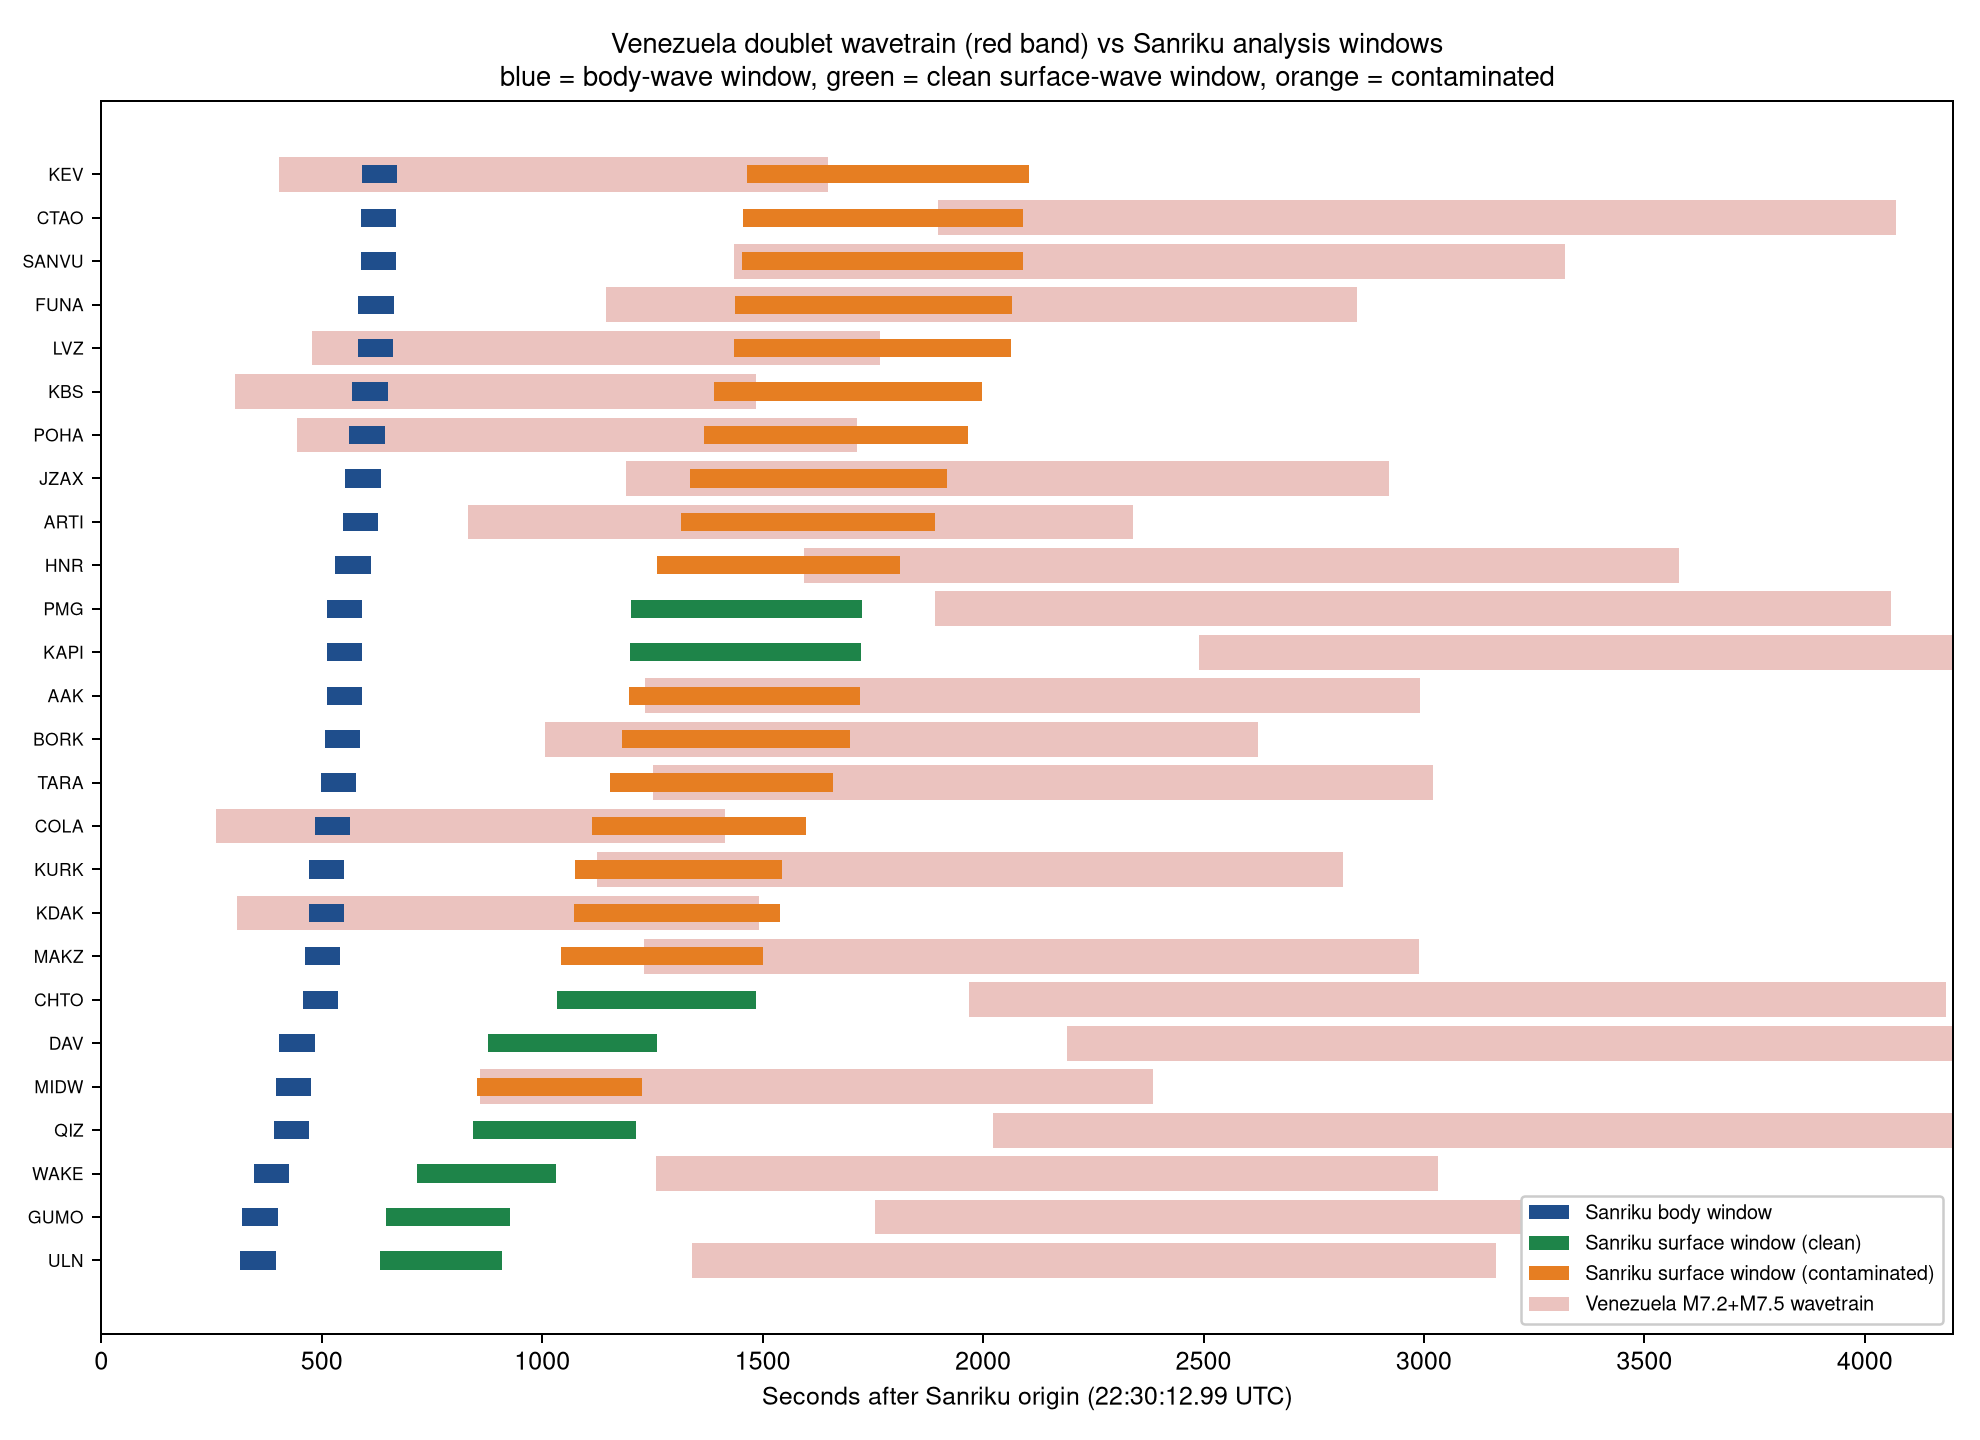

In [2]:
display(Image(os.path.join(B,'event_2026_sanriku/contamination_timeline.png')))

**How the red band is computed:** for each station, great-circle distance from the Venezuela
M7.5 epicentre d_V; onset = foreshock origin (−1540 s) + d_V/4.7 km/s (fastest Love), end =
mainshock origin (−1502 s) + d_V/2.9 km/s (slow Rayleigh tail) — a conservative group-velocity
envelope from the epicentral distance (point-source approx.; finite-source timing error ±50 s).
**Empirical validation below:** at TARA (flagged contaminated) the Venezuela Love onset lands
exactly inside the Sanriku surface window — the two events' wavetrains coincide and cannot be
separated. At QIZ (flagged clean) the Sanriku surface waves arrive in the green window and the
(3× larger!) Venezuela train arrives ~1 800 s later, inside the predicted red band.

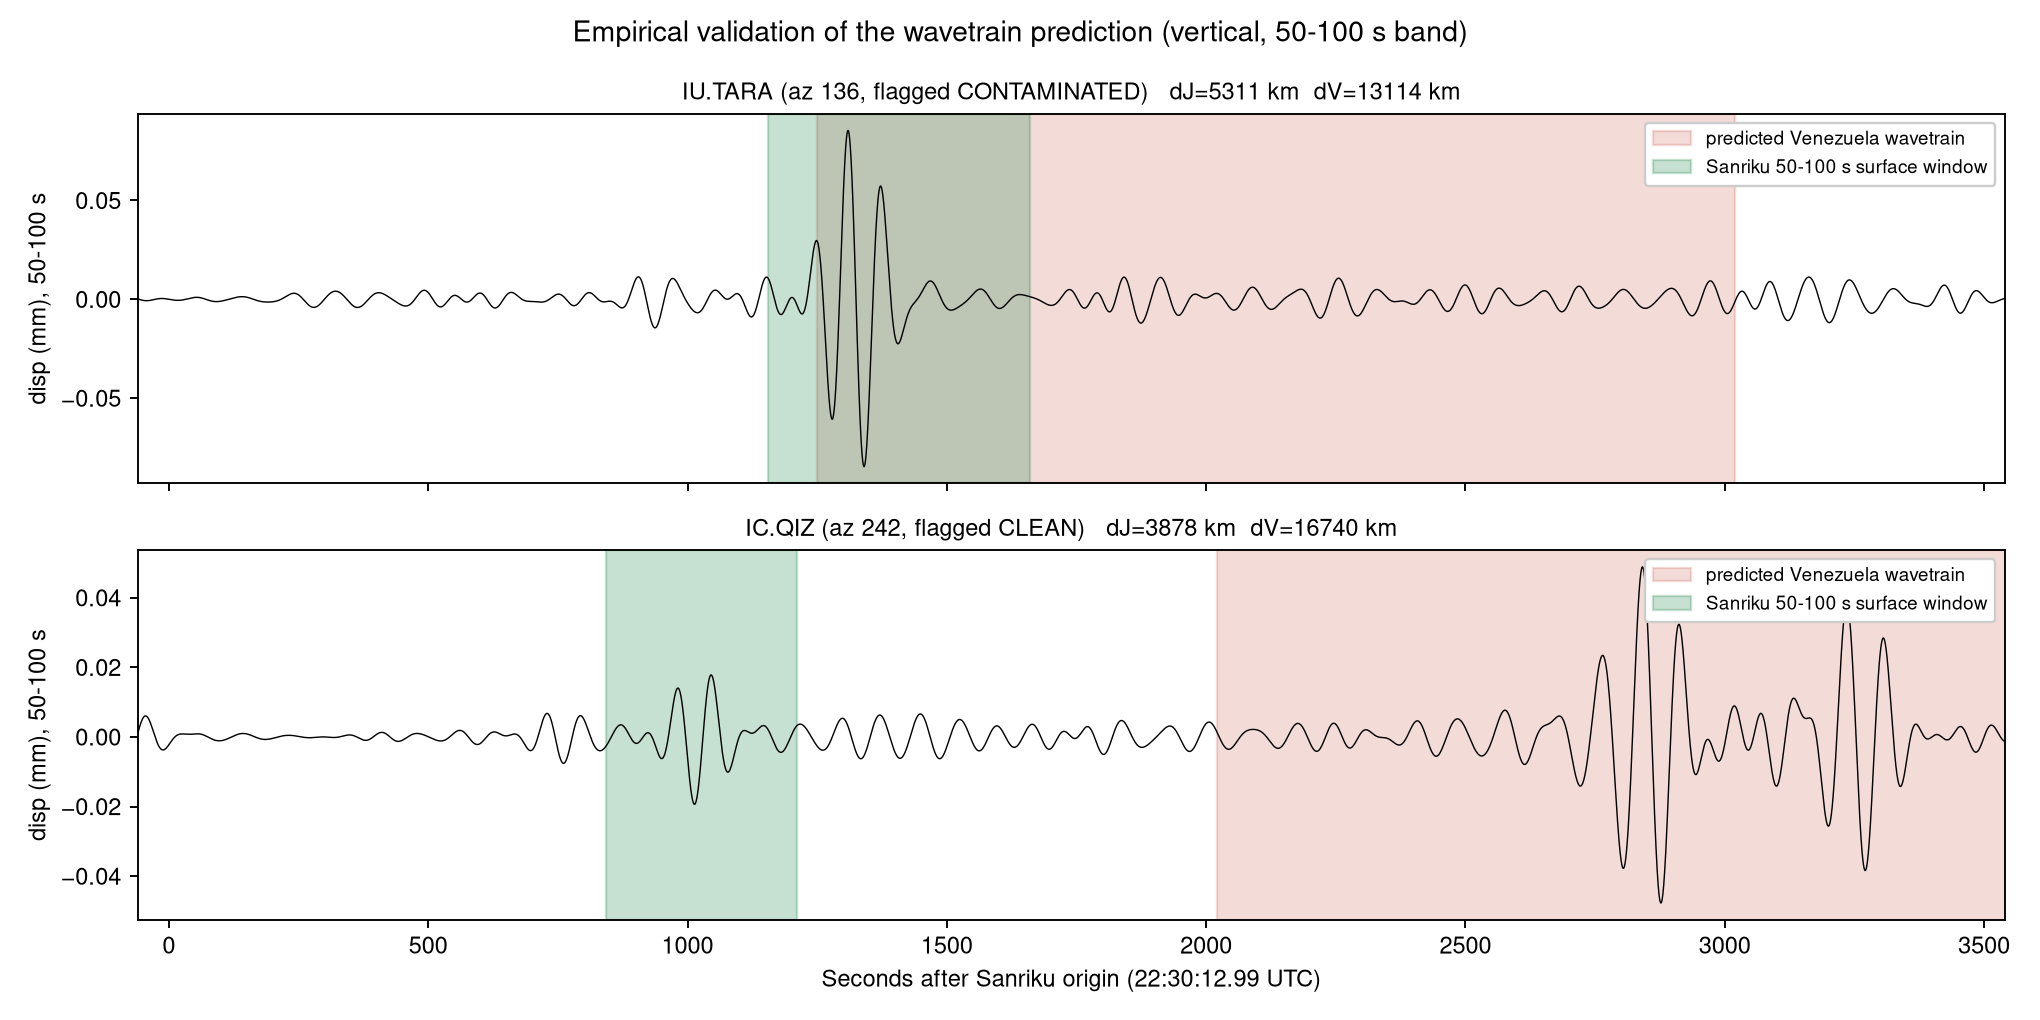

In [3]:
display(Image(os.path.join(B,'event_2026_sanriku/contamination_validation.png')))

## B. MTUQ moment tensor
Teleseismic GSN 3-C, 25–75°; body 10–33 s (20 clean stations), surface 50–100 s (**8 clean
stations only** — contamination QC via CAP weights). Full-MT and DC agree; the depth search has a
clear minimum at **46 km ≈ the USGS W-phase centroid (45.5 km)**, not the 34-km catalog hypocentre.

| run | Mw | strike/dip/rake | note |
|---|---|---|---|
| full-MT (34 km) | 6.90 | 198/18/81 | thrust, interface family |
| DC (34 km) | 6.90 | 194/16/74 | |
| **DC + depth search** | **6.90** | **184/24/65 @ 46 km** | best depth 46 km |
| USGS Mww | 6.9 | 177/31.5/60 @ 45.5 km | reference |

**VR (clean stations): surface 64.7 %, body 8.5 %.** The body-wave *shapes* correlate (cc 0.7–0.9)
but synthetic amplitudes are systematically low — consistent with **slab-path amplification**
(high-Q slab takeoff under-predicted by 1-D ak135f), a known Japan-slab effect; the mechanism is
carried by the surface waves + body shapes.

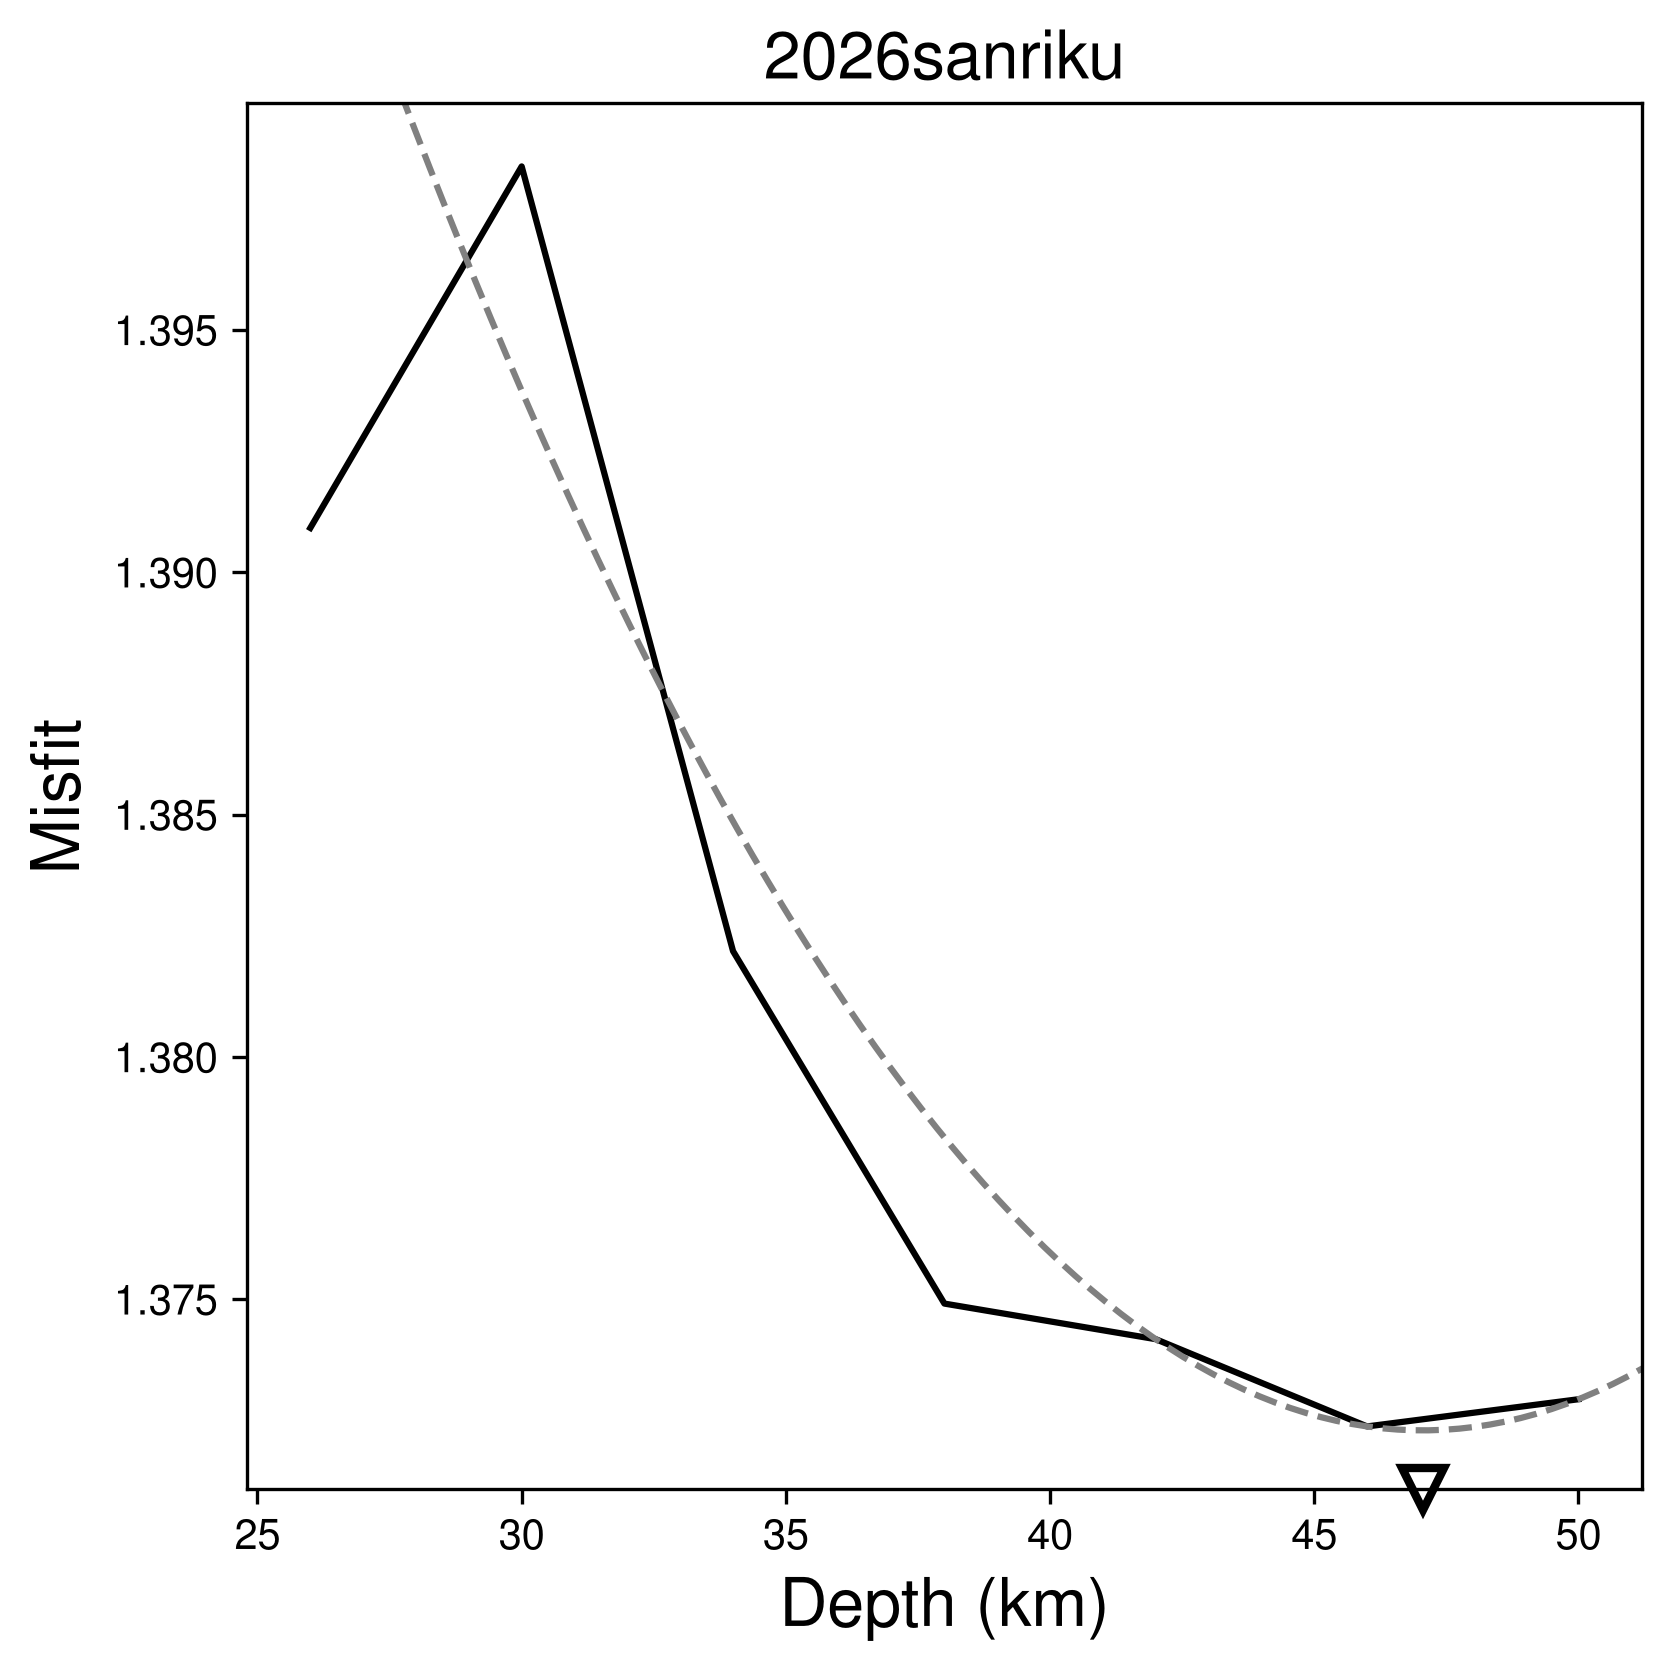

In [4]:
display(Image(os.path.join(R,'mtuq_dcz_2026sanriku/2026sanriku_misfit_depth.png')))

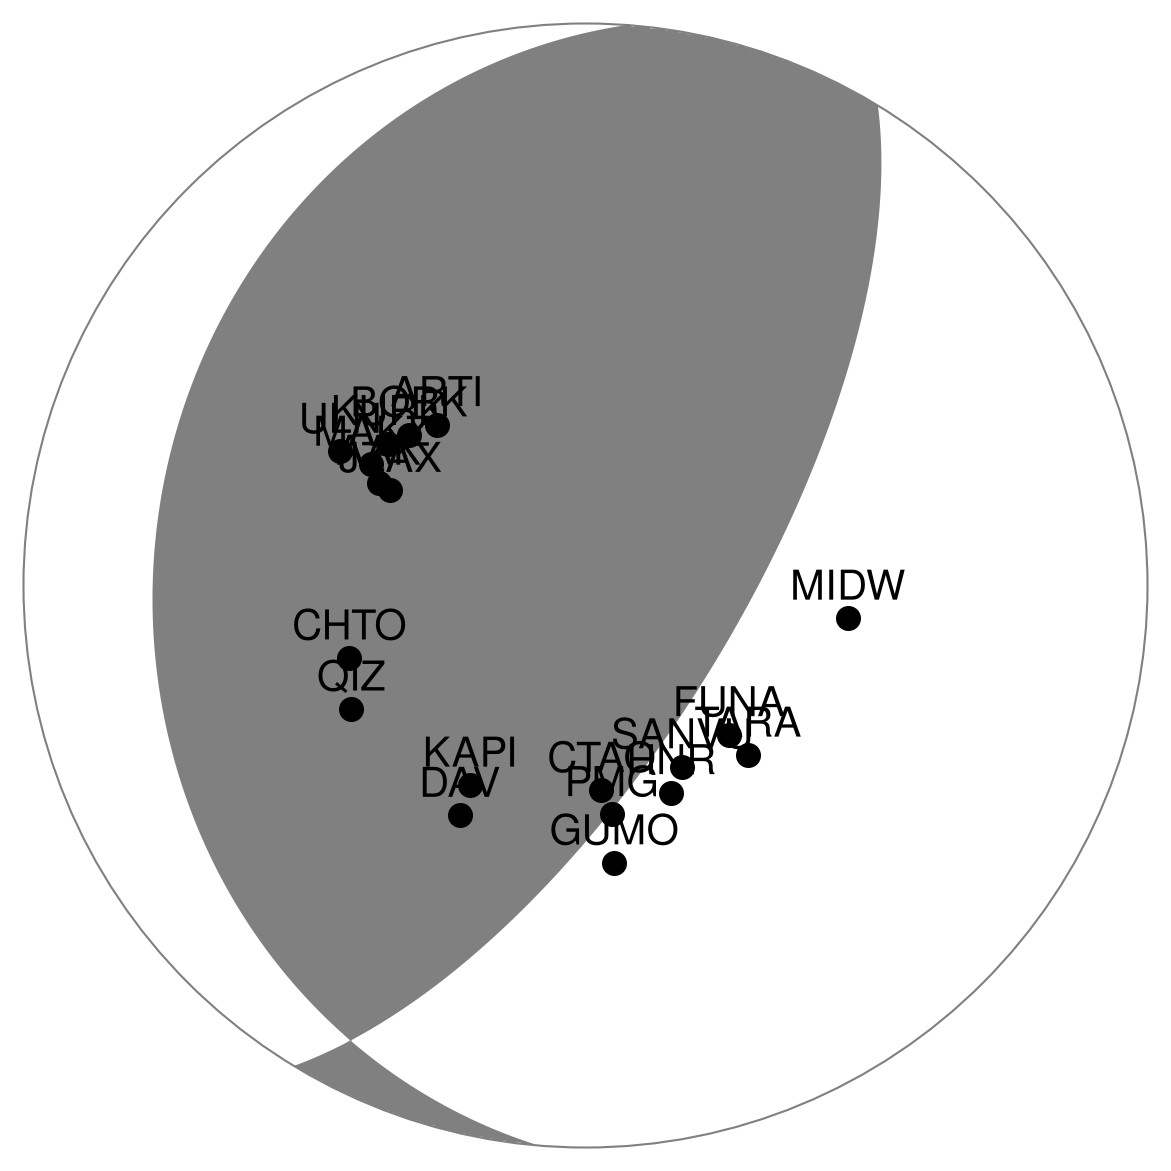

In [5]:
display(Image(os.path.join(R,'mtuq_dc_sanriku_d46/sanriku_d46_beachball.png')))

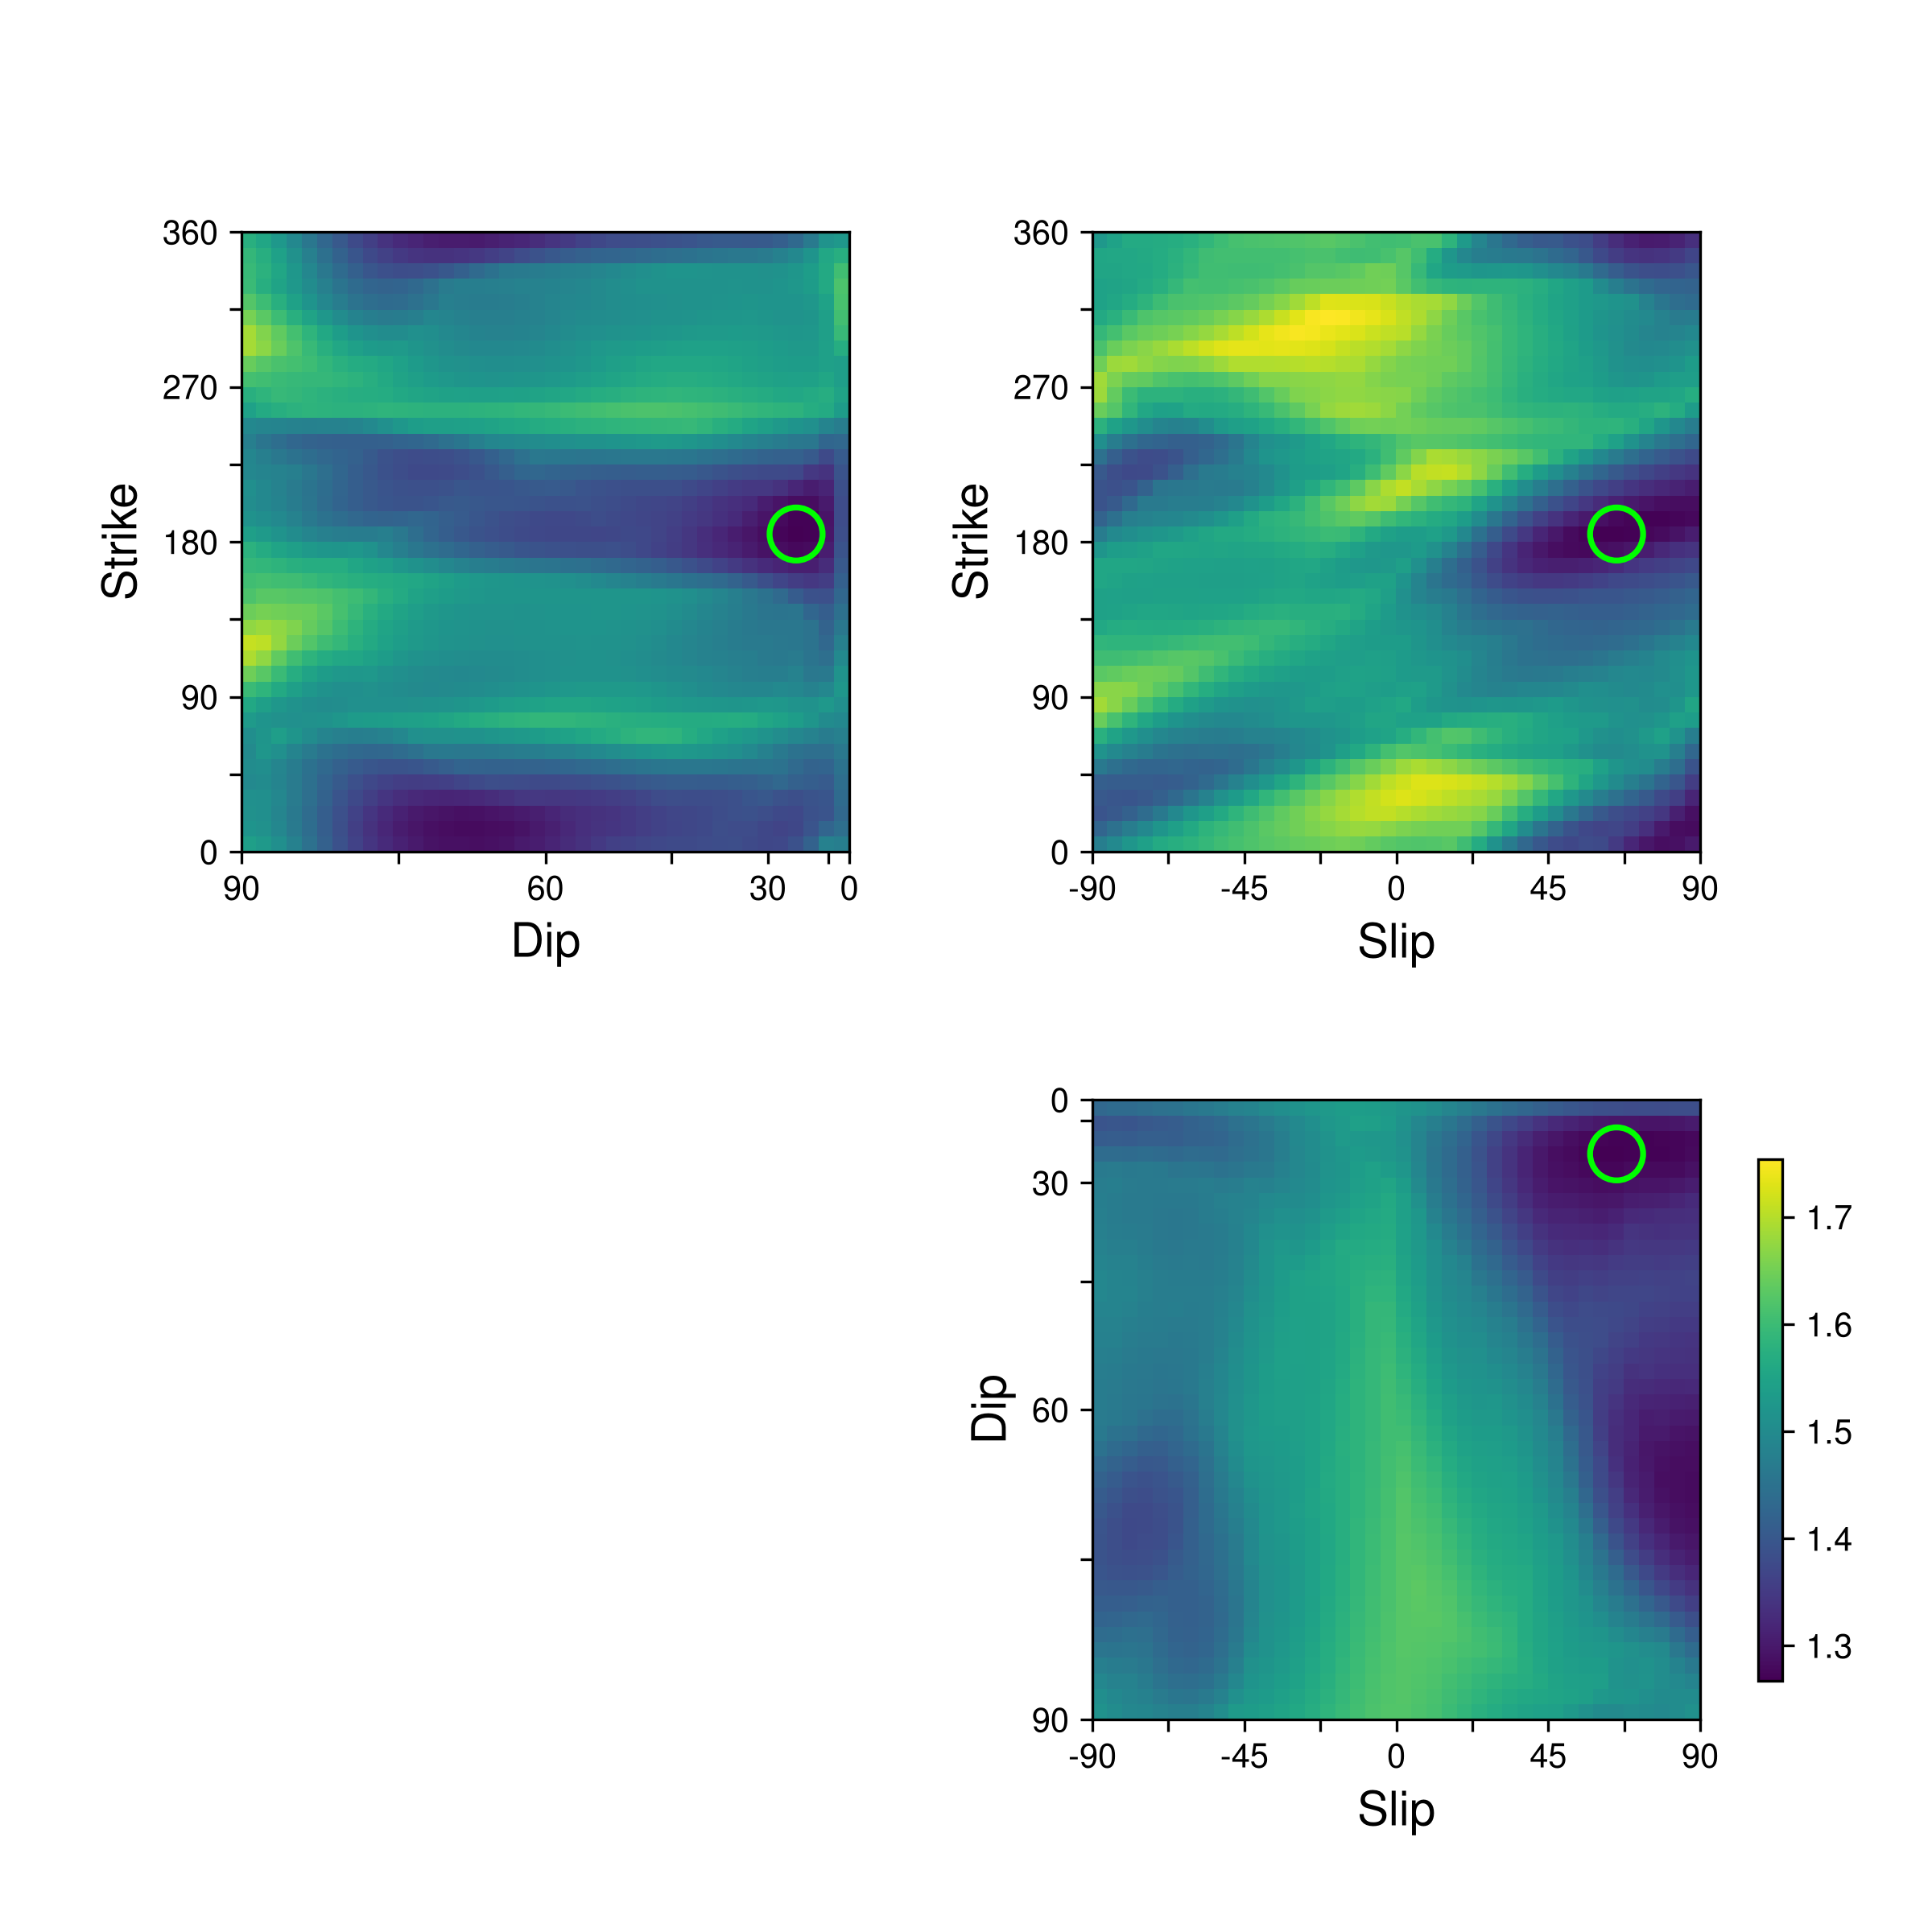

In [6]:
display(Image(os.path.join(R,'mtuq_dc_sanriku_d46/sanriku_d46_misfit_dc.png')))

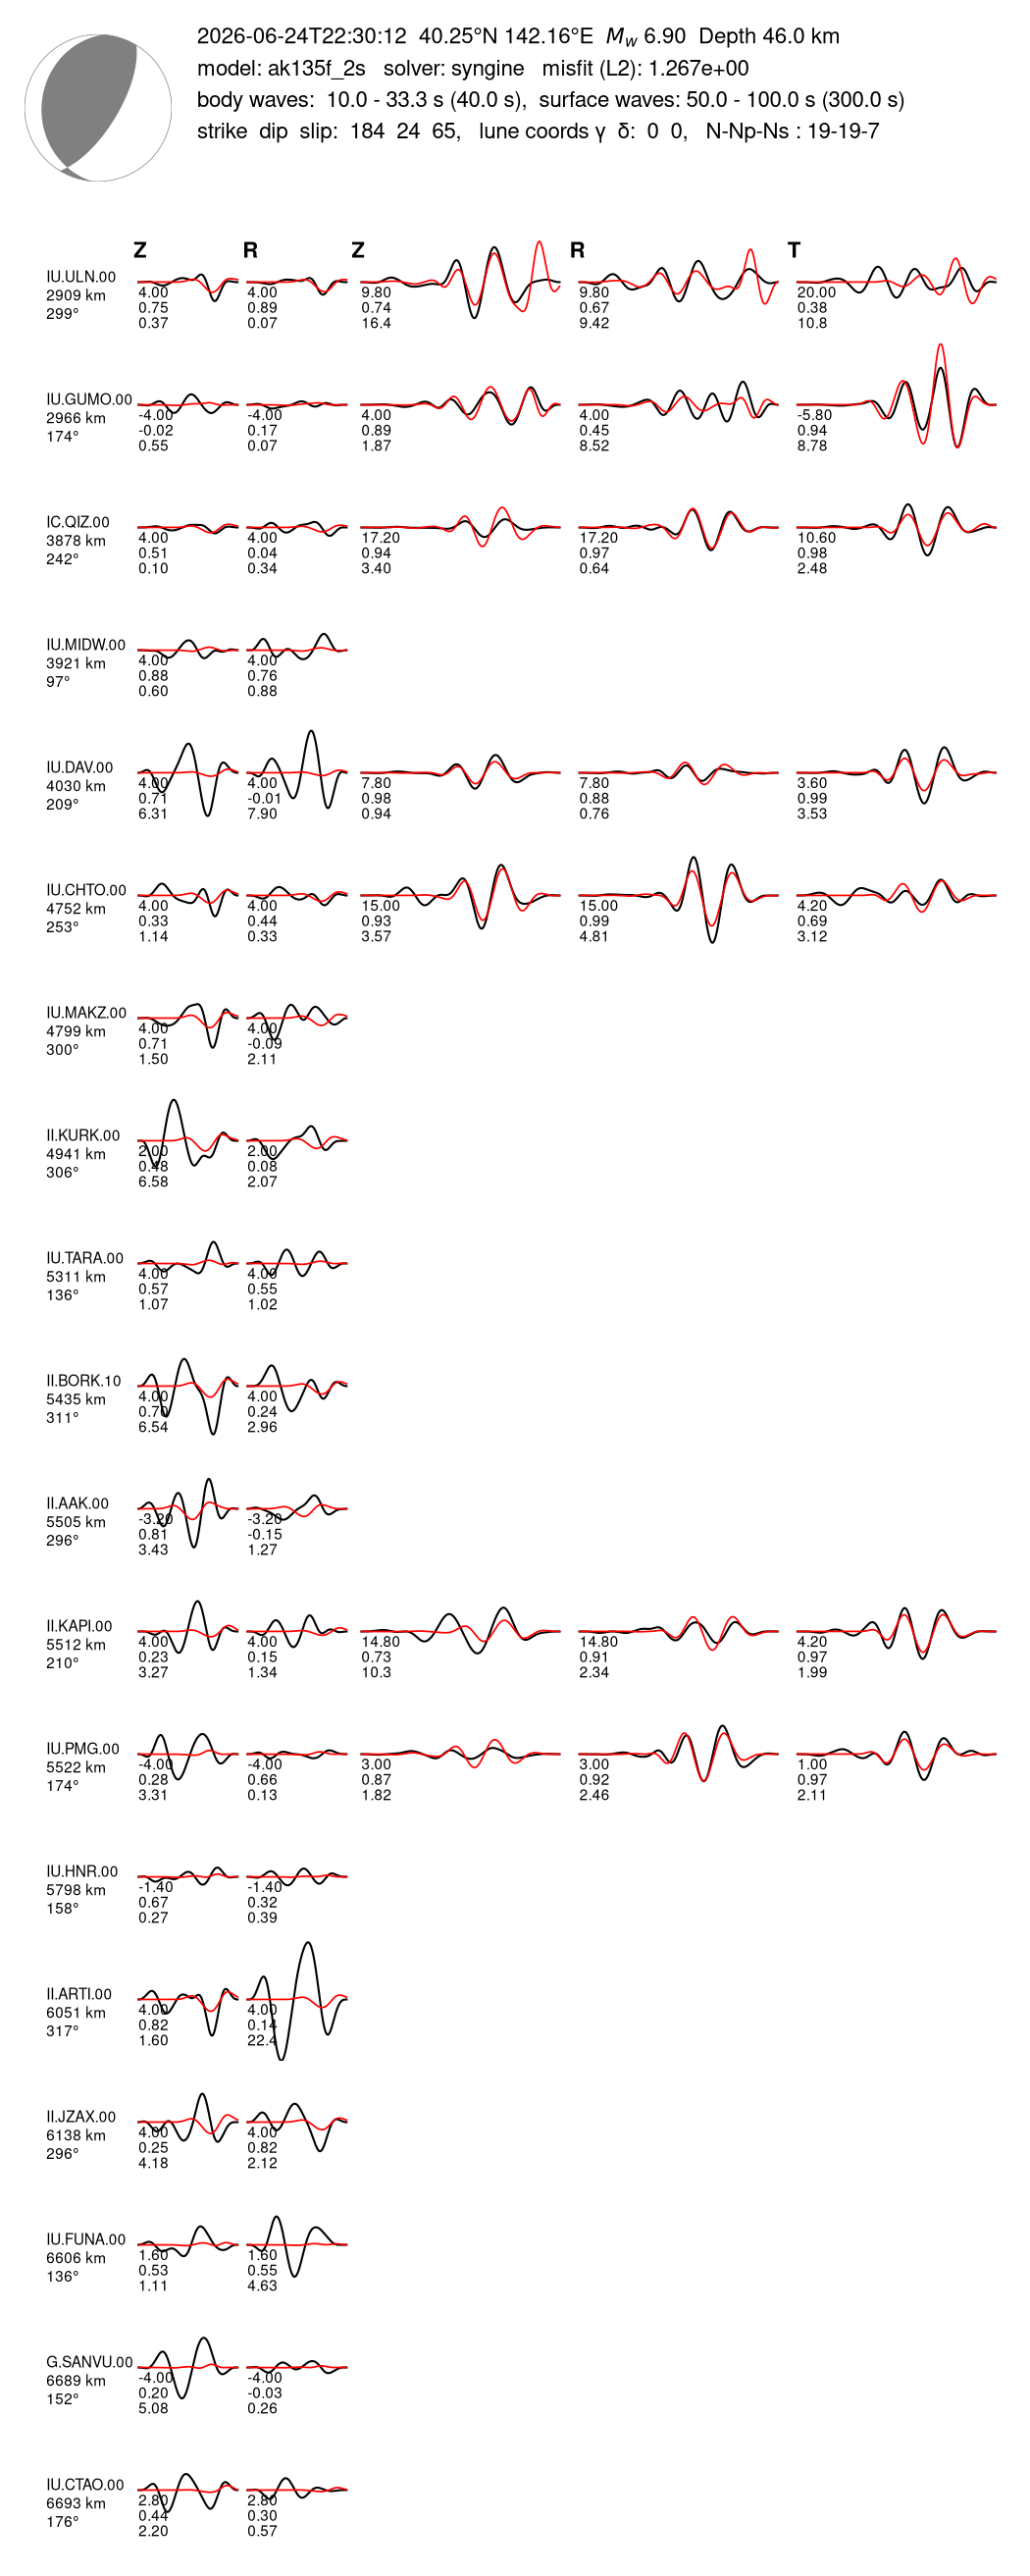

In [7]:
display(Image(os.path.join(R,'mtuq_dc_sanriku_d46/sanriku_d46_waveforms.png')))

## C. WISP finite-fault (strict CLI pipeline)
Auto model, both planes (identical misfit 0.166 — conjugates indistinguishable teleseismically):
NP1 32/63 (steep) vs **NP2 177/31 (Japan Trench interface — tectonically required choice)**.
Refined run (`NP2_ref`): Venezuela contamination QC + shift_match. **A finding in itself:
WISP's own SNR-based station selection rejected ALL 74 processed P channels (SNR<5 — M6.9
teleseismic P sits at the microseism noise floor), so the auto model was SH+surface only.**
We force-included 14 MTUQ-validated, contamination-clean P stations (selection bypass);
final misfit 0.211 with 14 P + 8 clean SH + 3 clean surface channels.

**NP2_ref (preferred):** Mw 6.92, peak slip 1.33 m, compact patch at 23–44 km depth on the
31°-dipping interface — consistent with the MT depth (46 km) and a typical Sanriku-oki interplate
asperity.

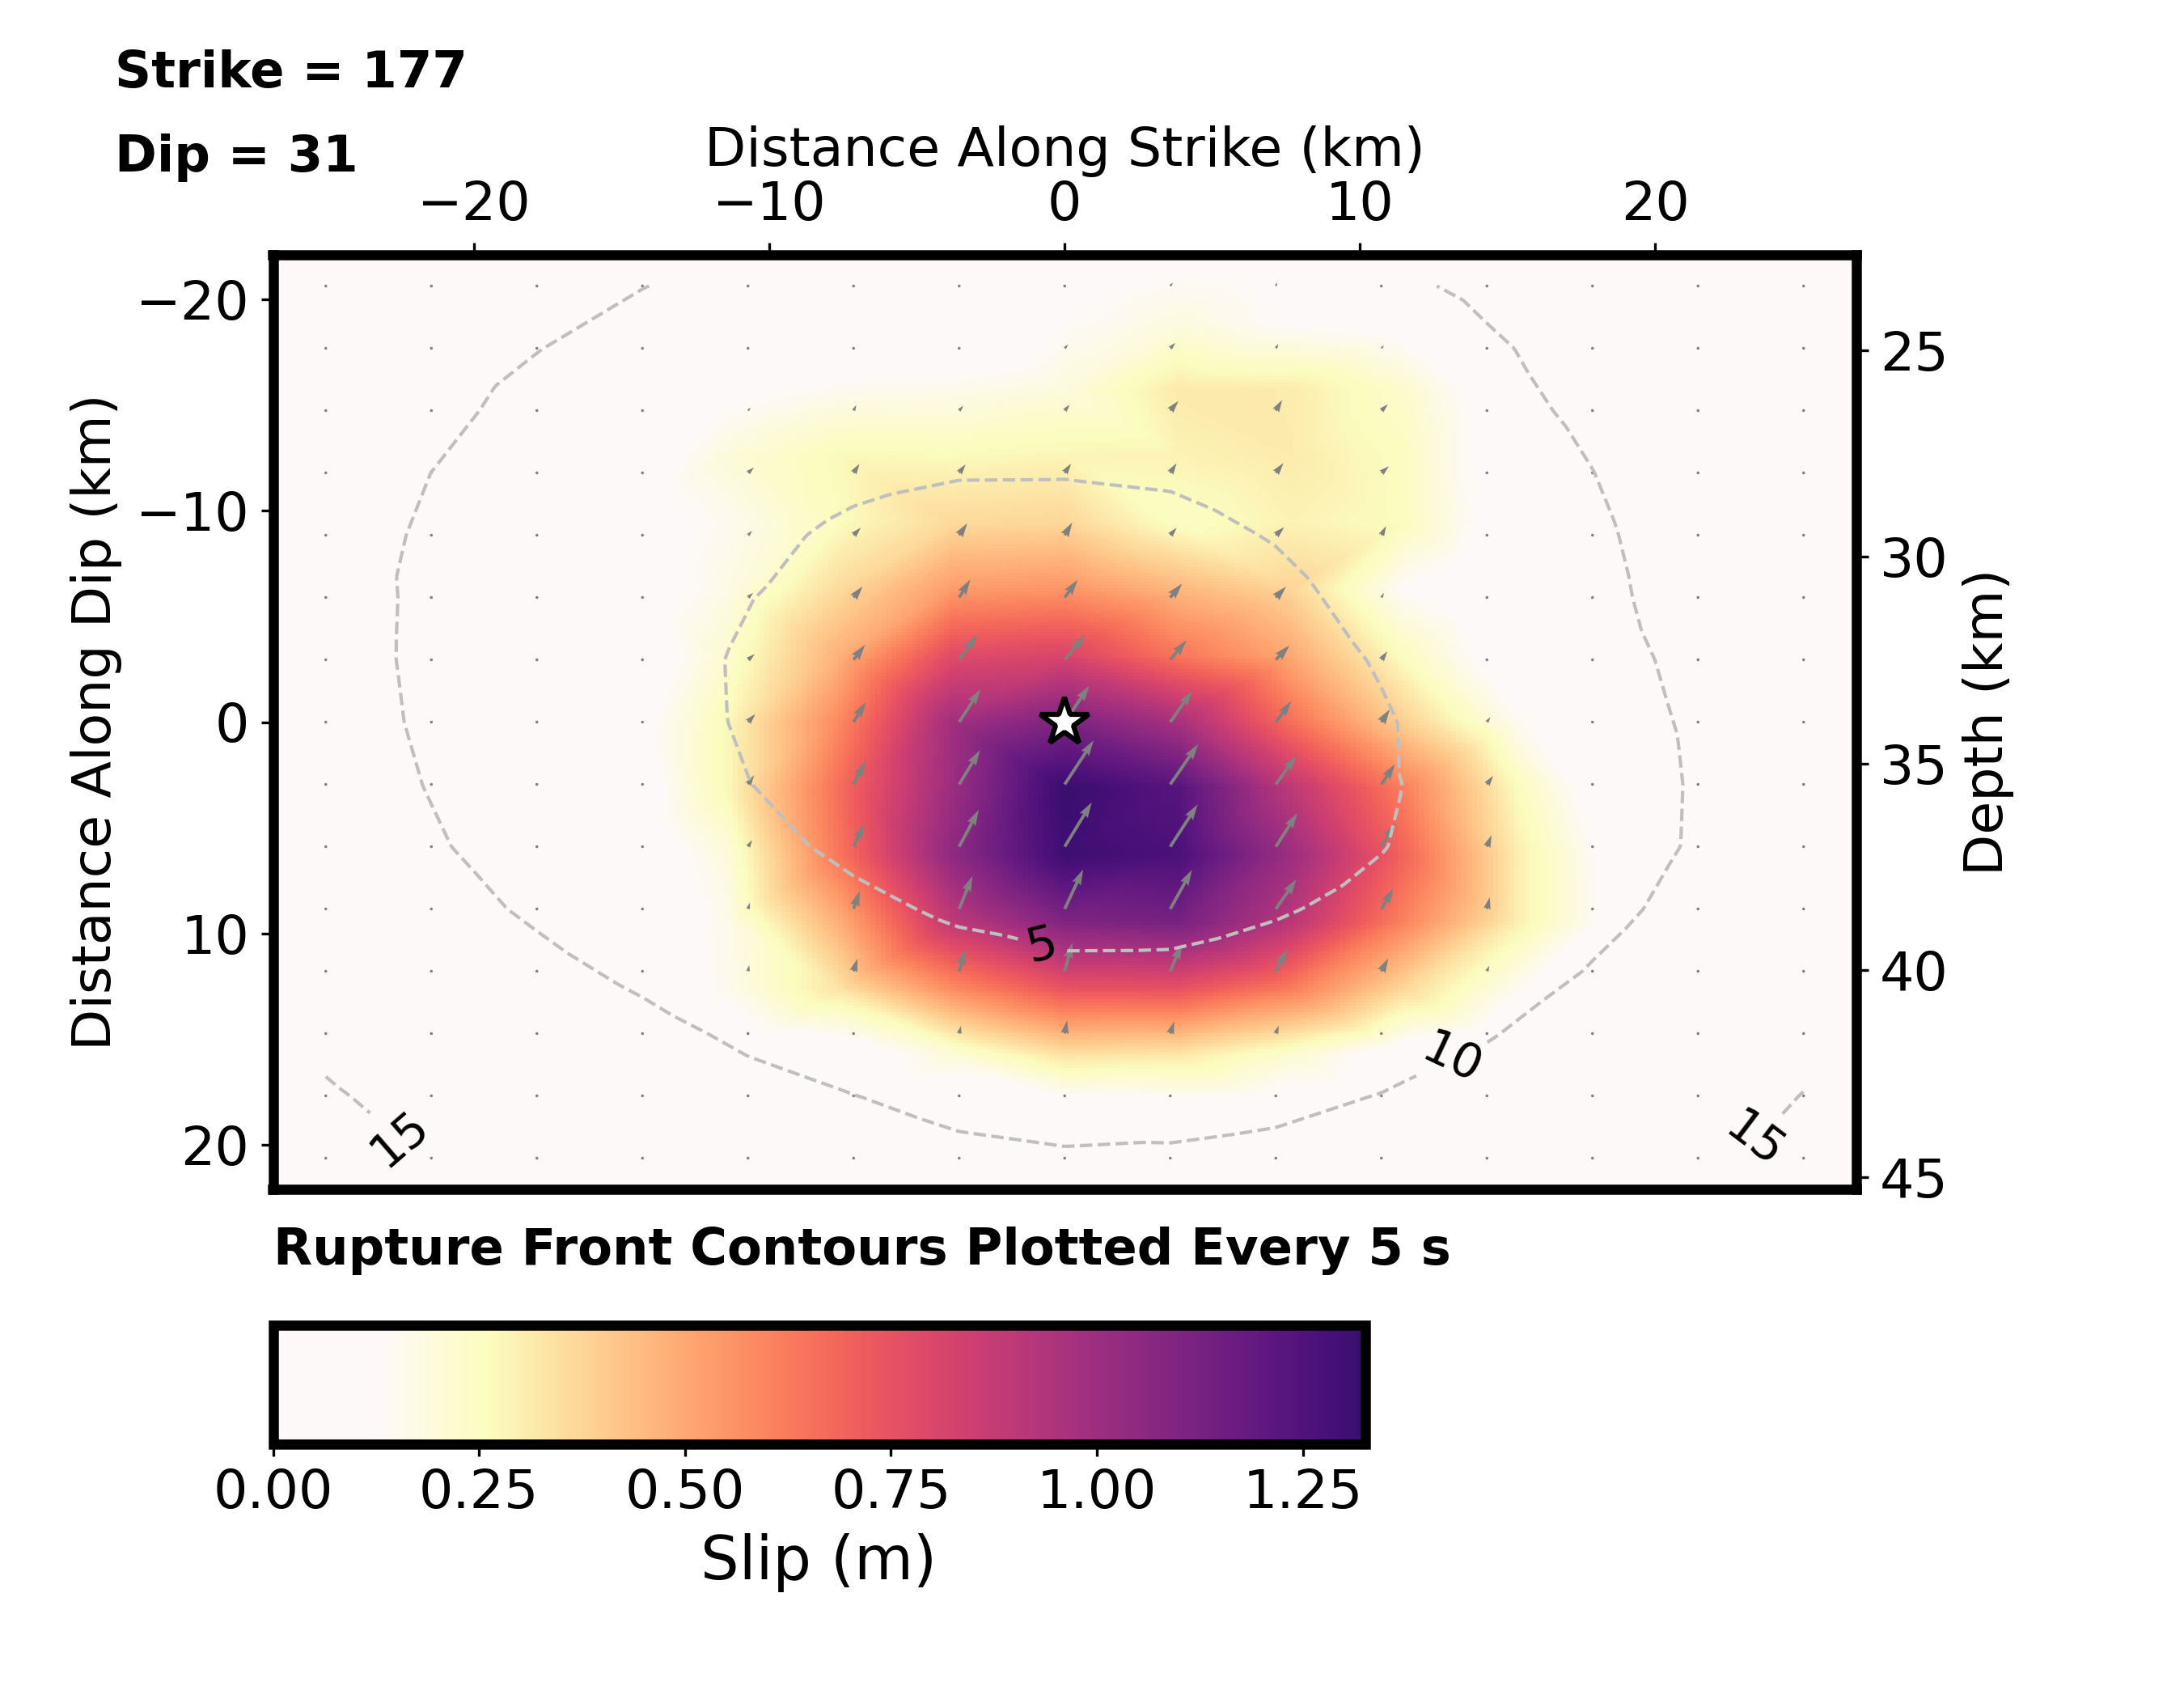

In [8]:
display(Image(os.path.join(E,'NP2_ref/plots/SlipDist_plane0_5s.png')))

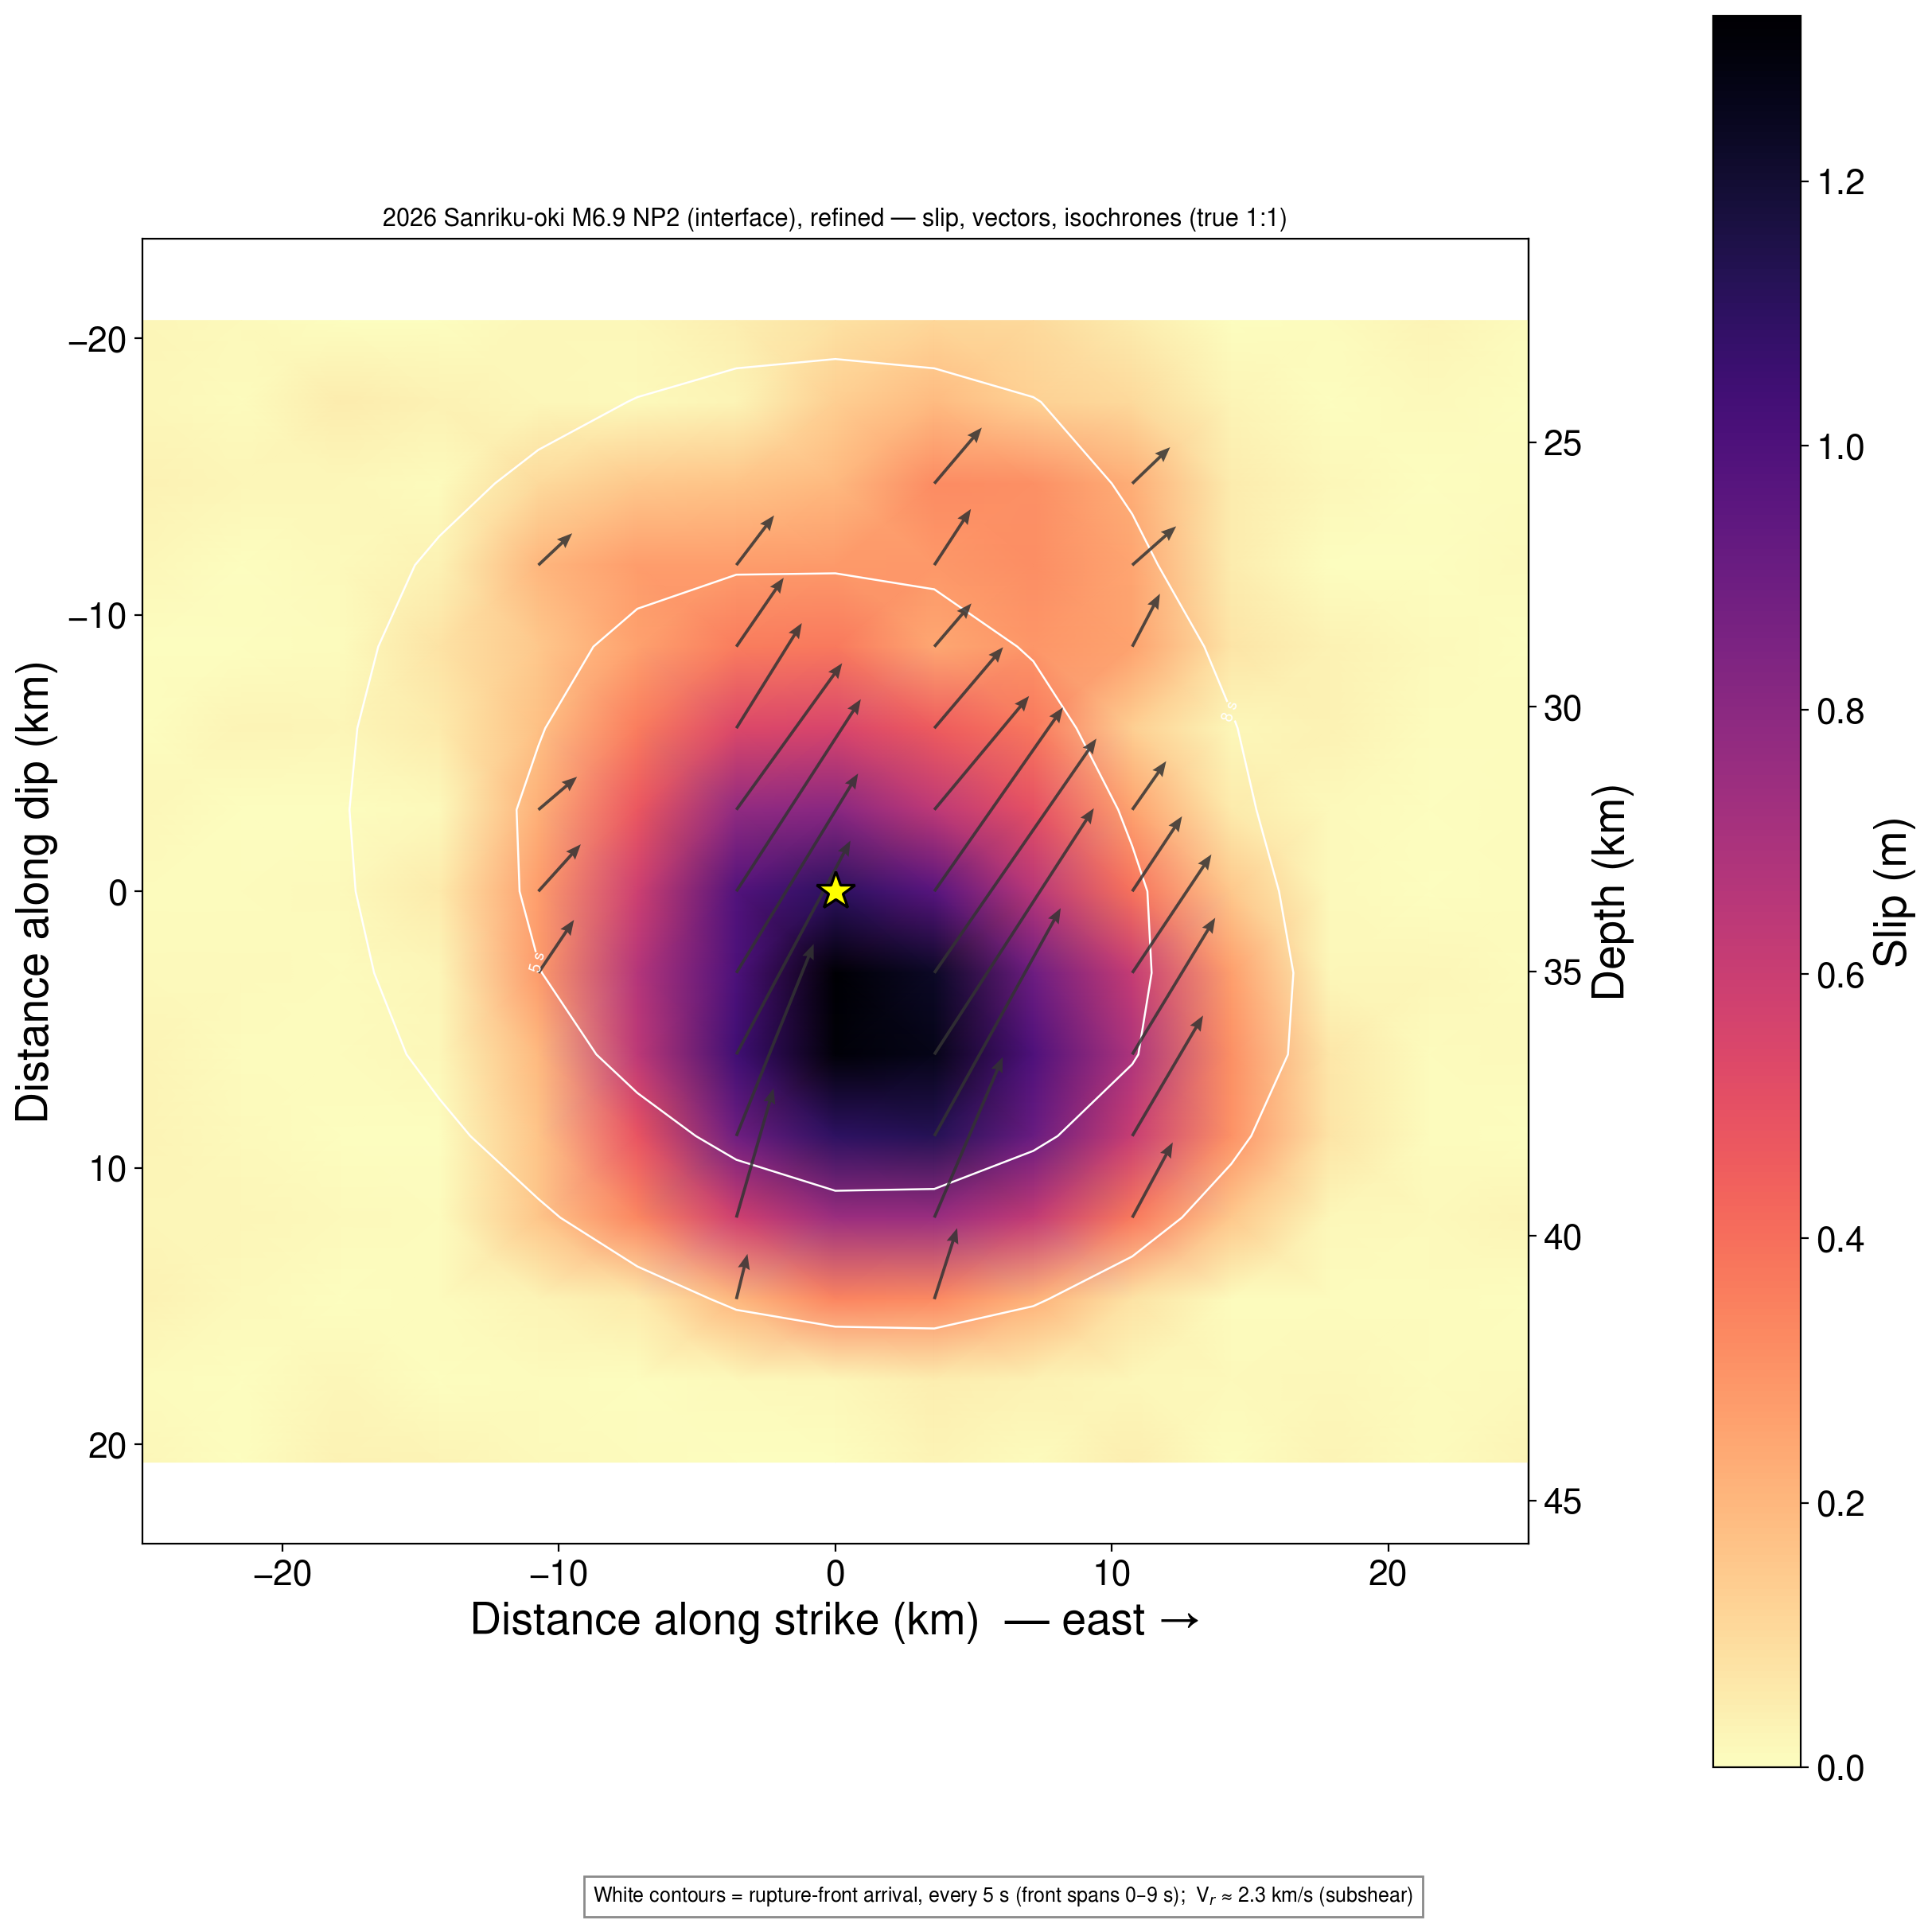

In [9]:
display(Image(os.path.join(E,'NP2_ref/plots/SlipIsochrone_trueScale.png')))

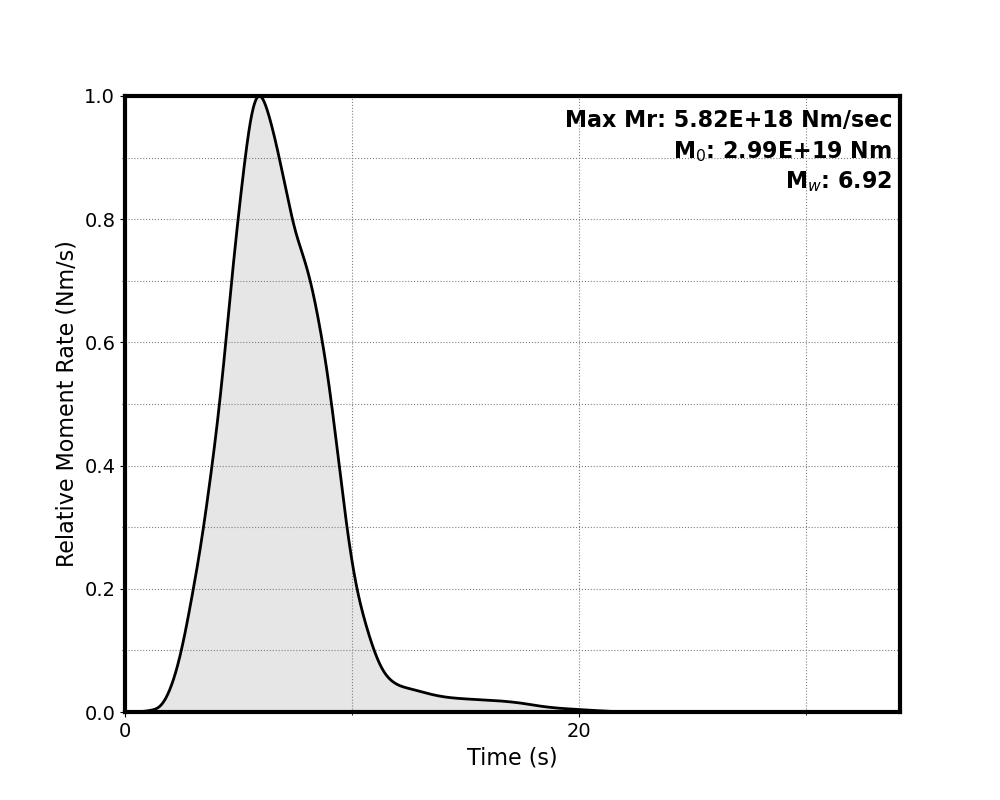

In [10]:
display(Image(os.path.join(E,'NP2_ref/plots/MomentRate.png')))

### C1. Waveform fits (refined, clean channels; faded = rejected)

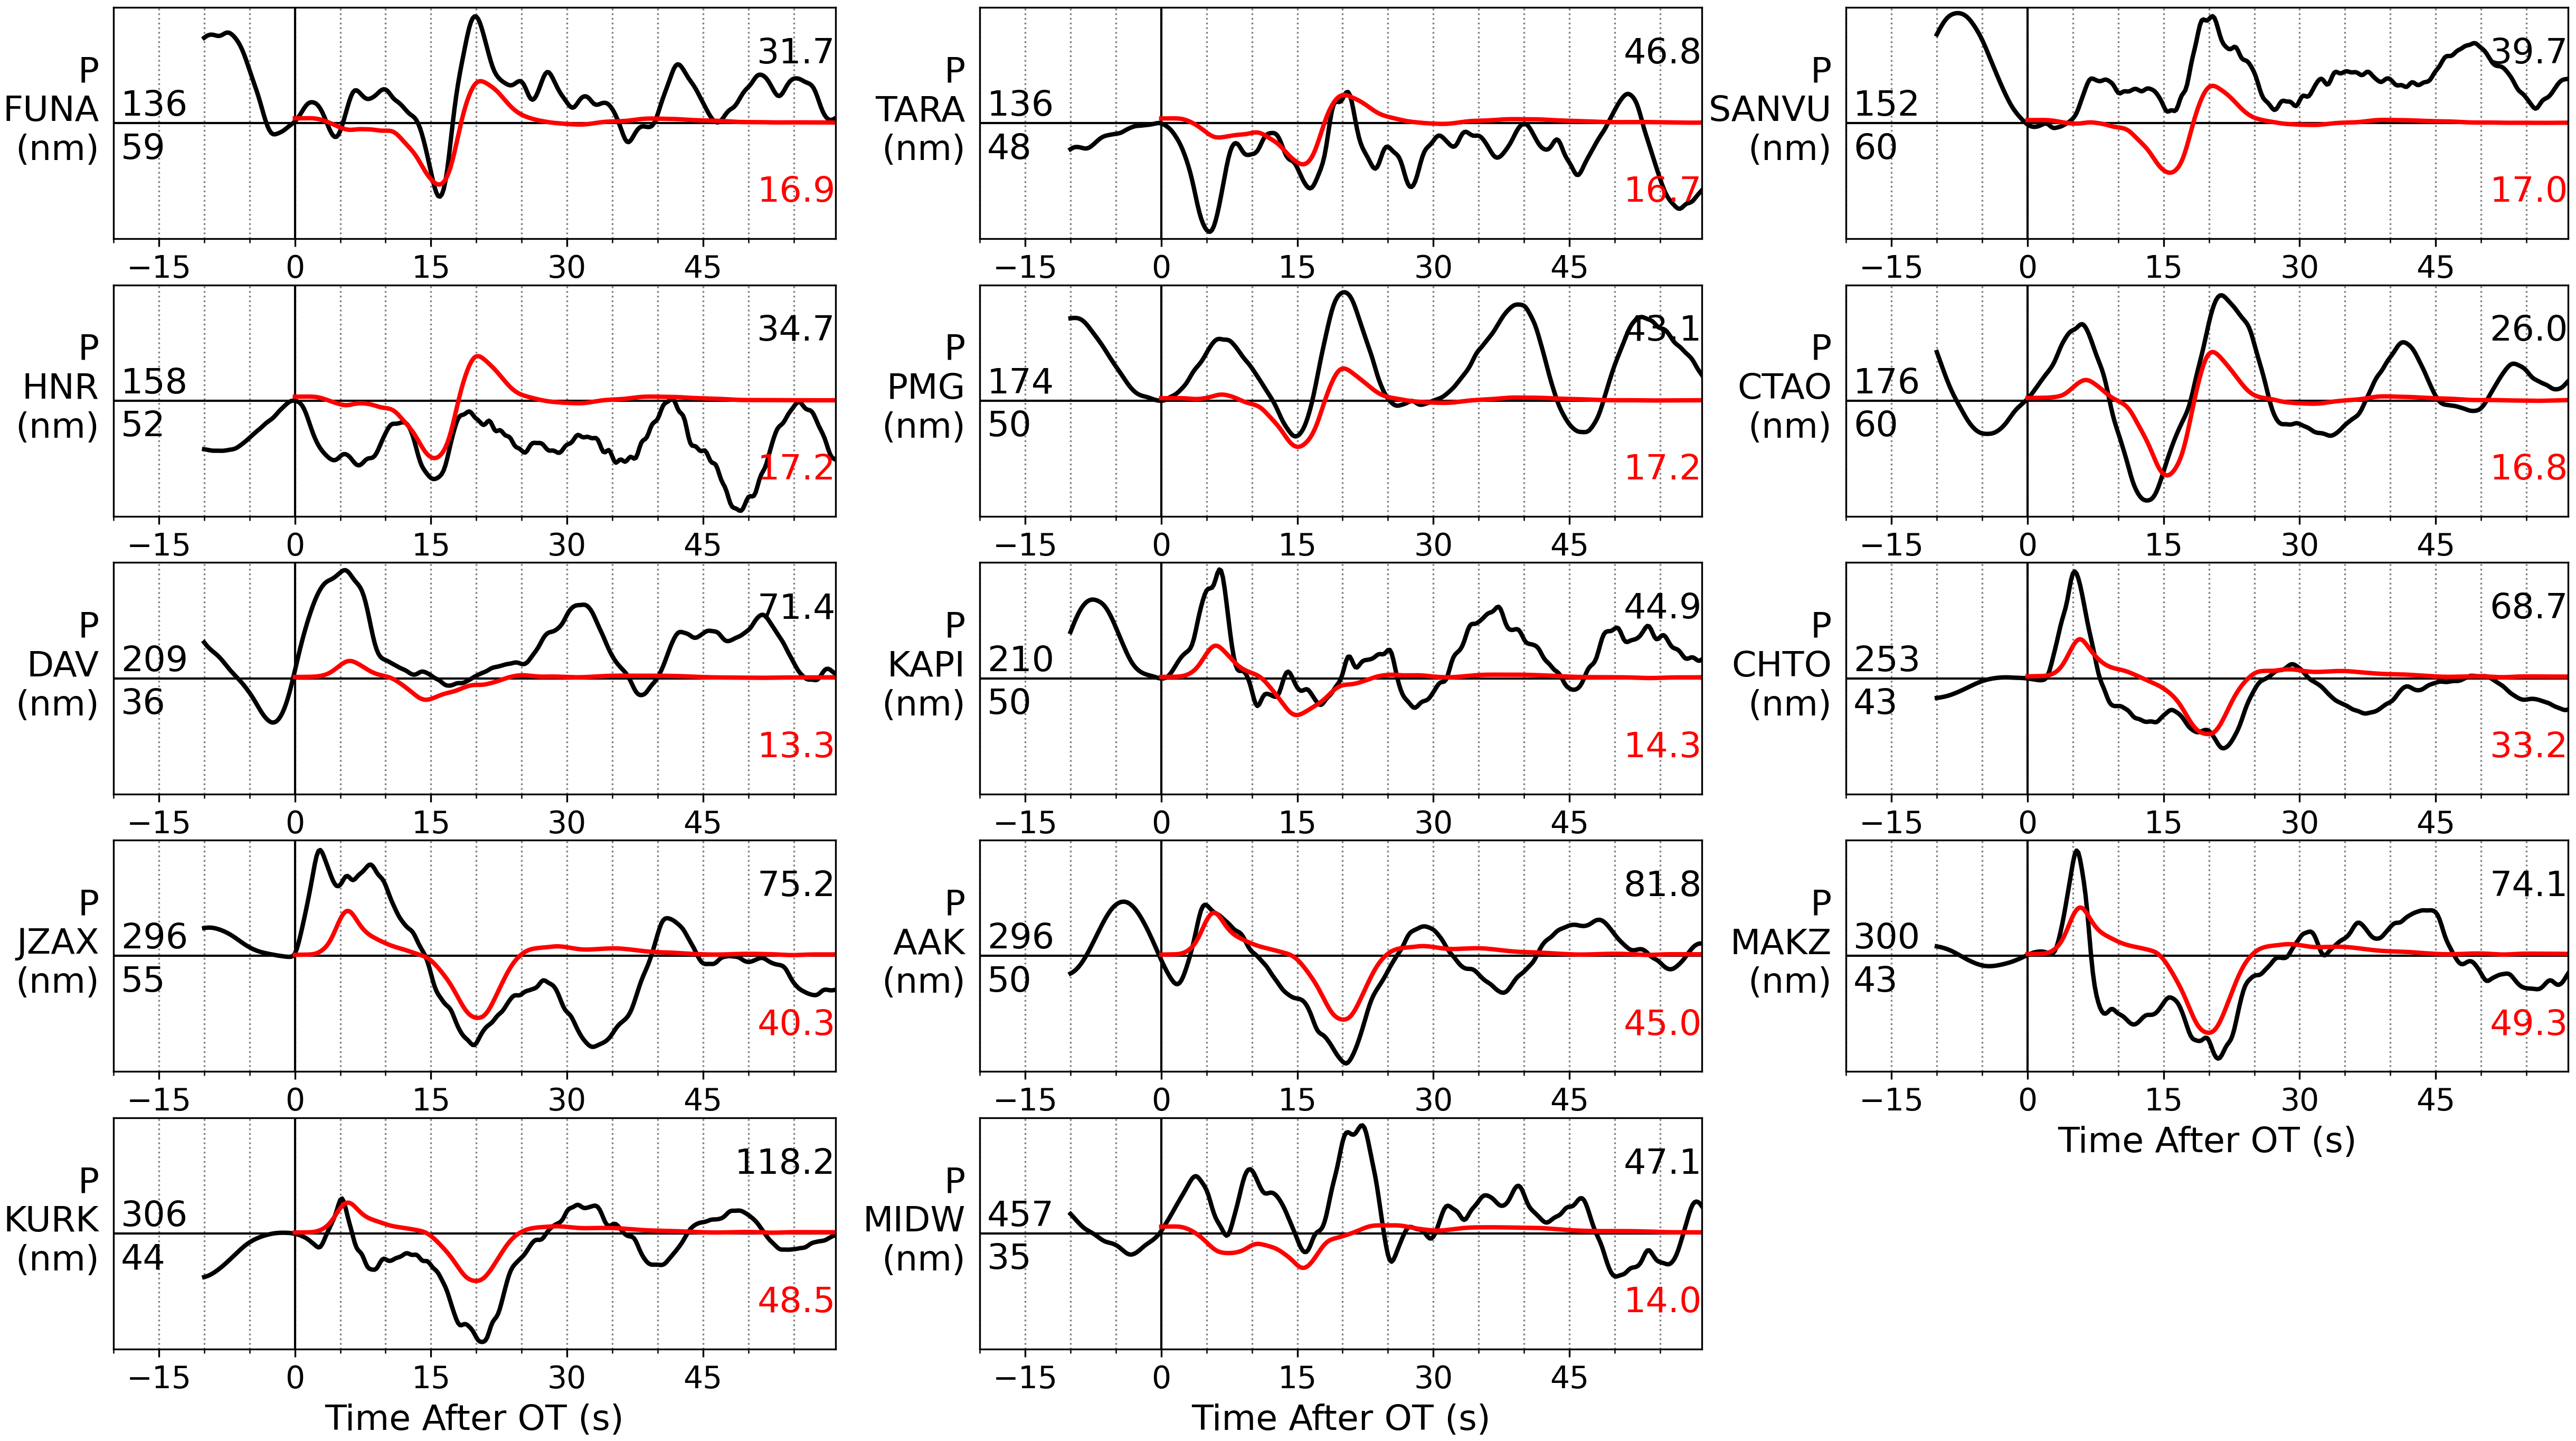

In [11]:
from imgutil import trim
display(Image(trim(os.path.join(E,'NP2_ref/plots/P_body_waves.png'))))

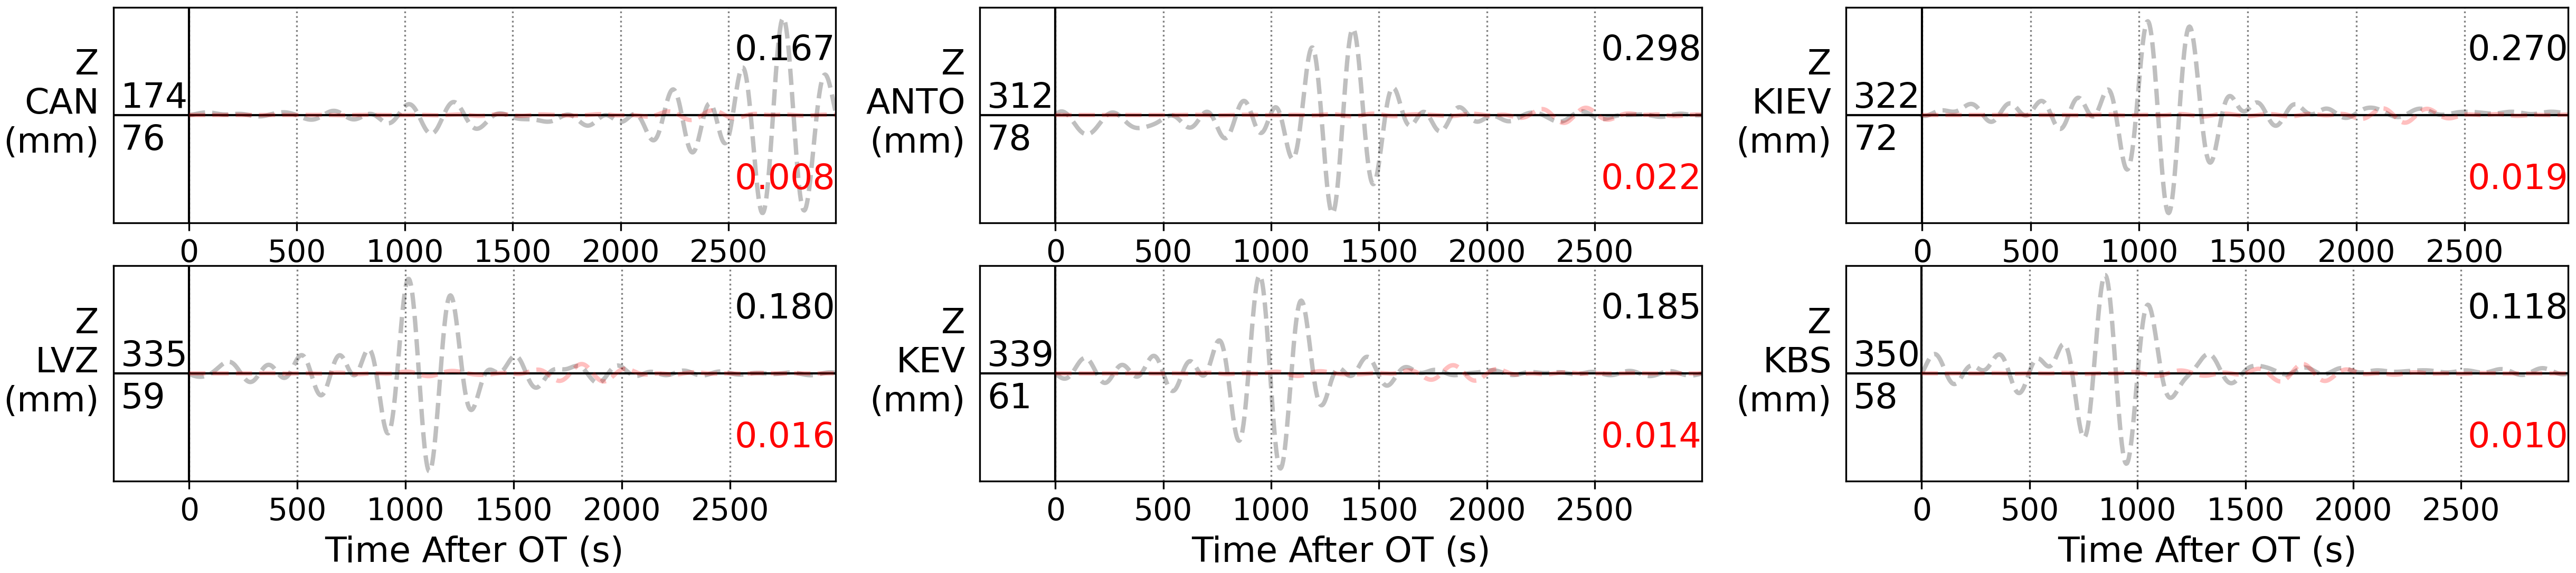

In [12]:
display(Image(trim(os.path.join(E,'NP2_ref/plots/Rayleigh_surf_waves.png'))))

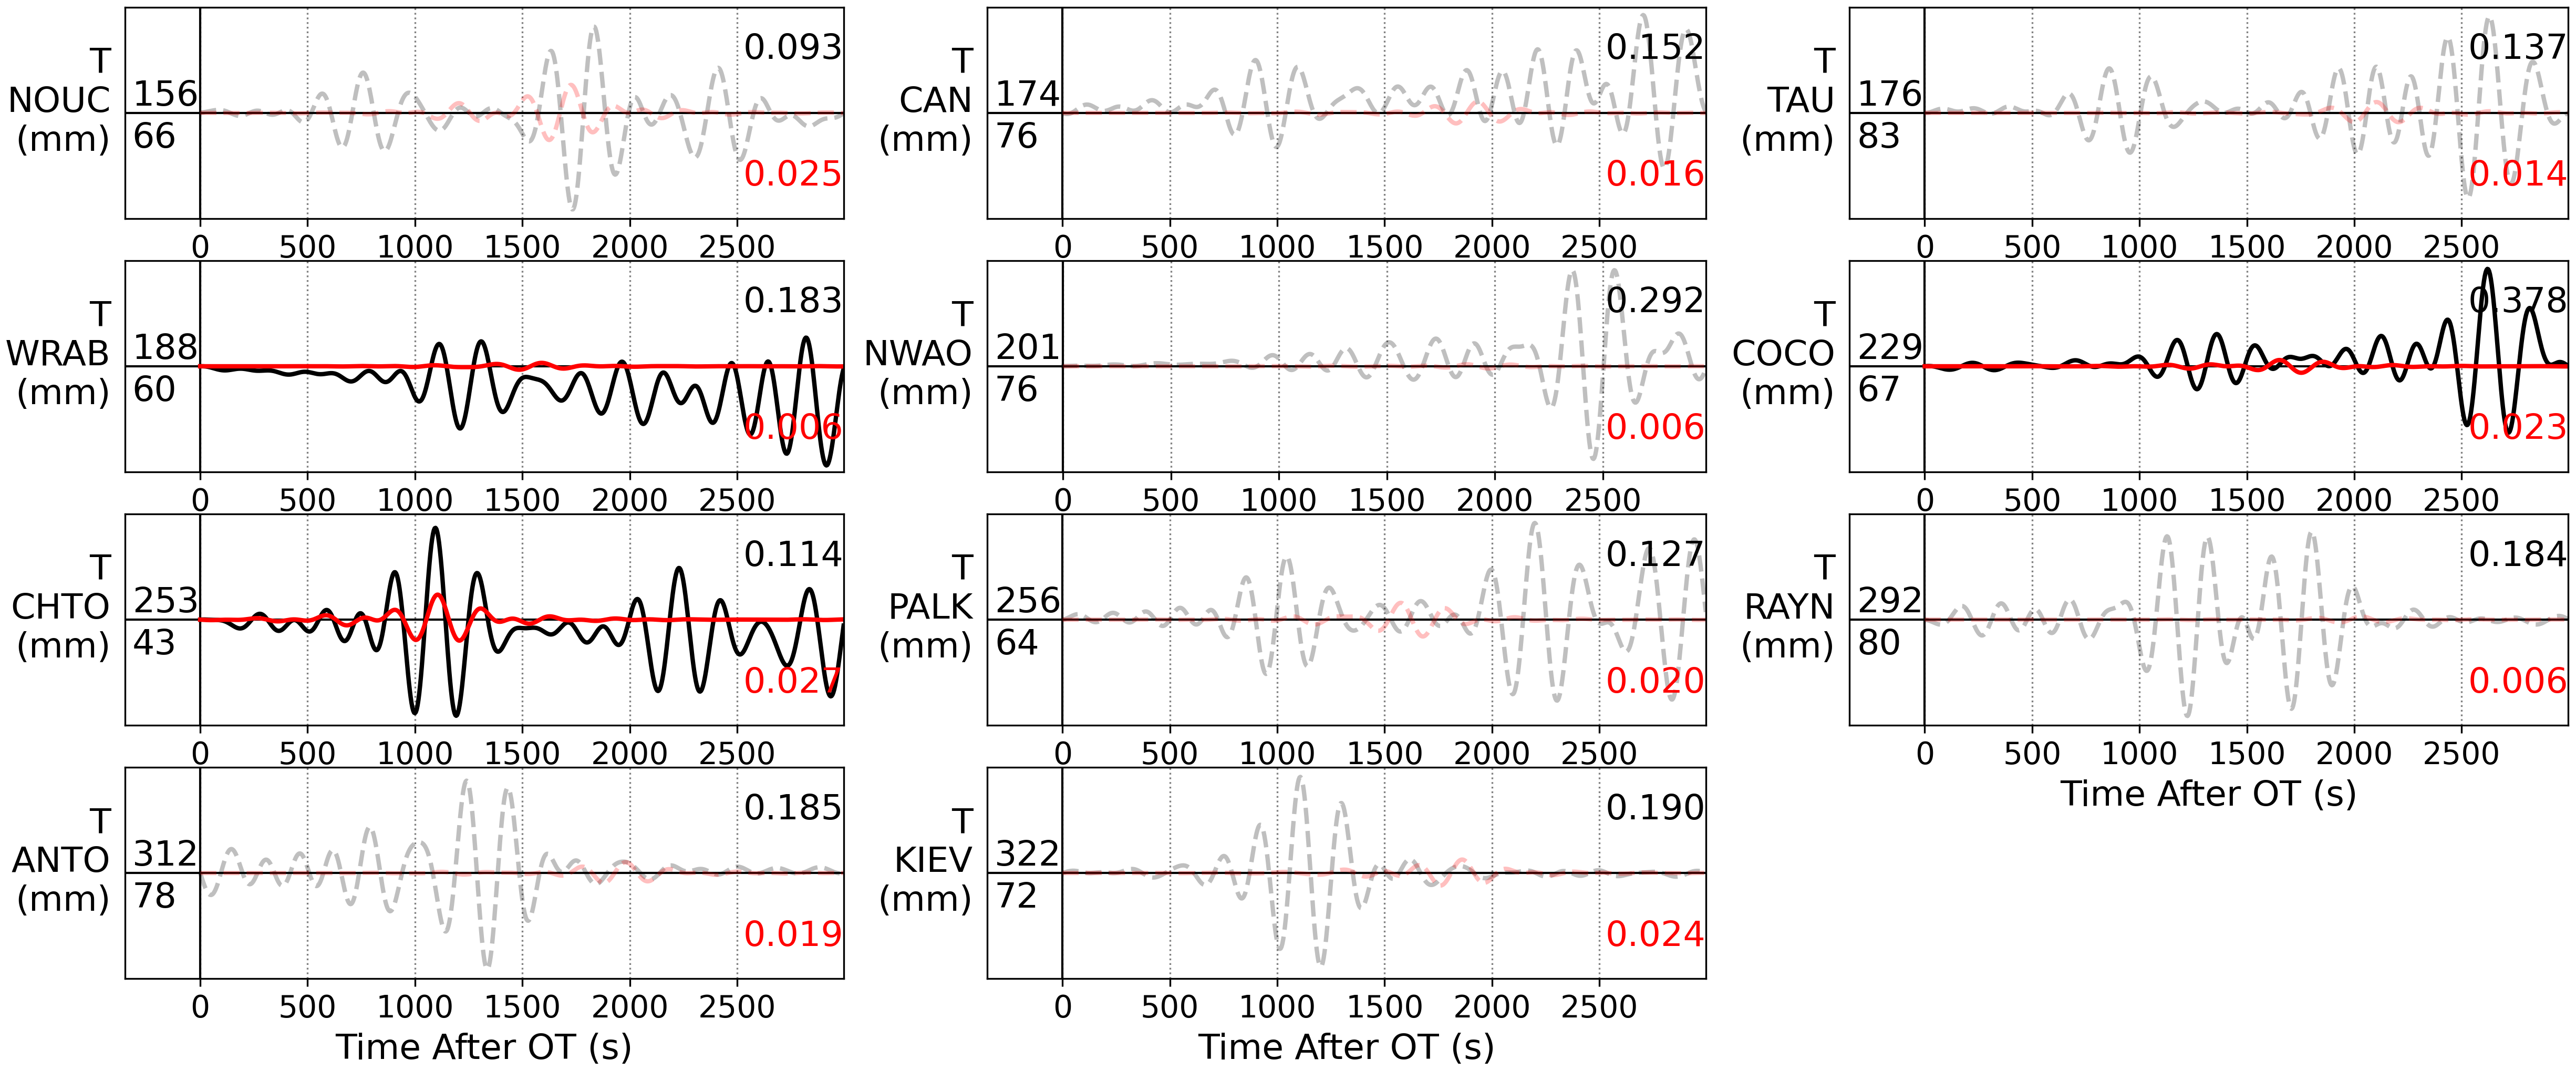

In [13]:
display(Image(trim(os.path.join(E,'NP2_ref/plots/Love_surf_waves.png'))))

## D. Honest verdict (the M6.9 threshold challenge)
- **Moment tensor: robust.** Mw 6.90, interface thrust within ~10–15° of USGS Mww, centroid depth
  46 km independently recovered (vs W-phase 45.5). The MT survives the contamination because its
  windows close before the Venezuela train arrives.
- **Finite fault: obtainable but marginal, exactly as the duration/period framework predicts**
  (M6.9, T≈13 s). The model delivers robust *first-order* content — a compact ~30–40 km interface
  patch, peak ~1.3 m, depth 23–44 km, Mw 6.92 — but after honest contamination QC only 11 clean
  channels remain, so internal slip detail, extent, and directivity should not be over-read
  (conjugate planes are misfit-indistinguishable; the interface choice is tectonic).
- **The missing-USGS-FFM hypothesis is supported:** 69 % of surface-wave and 23 % of body-wave
  windows are swept by the Venezuela doublet; a routine operational FFM would face the same
  data starvation we quantified.